In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os
from color_mapping import clean_color_column
from country_mapping import clean_country_column

file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)

official_apple_price = 949

model_discount = df[
    ["Preis", "Zustand", "Farbe", "Seller Rating", "Seller Type", "Herkunftsland"]
].copy()


def clean_price(x):
    if pd.isna(x):
        return np.nan
    x = (
        str(x)
        .replace("EUR", "")
        .replace("€", "")
        .replace(".", "")
        .replace(",", ".")
        .strip()
    )
    try:
        return float(x)
    except:
        return np.nan


def clean_rating(x):
    if pd.isna(x) or x == "N/A":
        return np.nan
    x = str(x).replace("%", "").replace(",", ".").strip()
    try:
        return float(x)
    except:
        return np.nan


model_discount["price"] = model_discount["Preis"].apply(clean_price)
model_discount["seller_rating"] = model_discount["Seller Rating"].apply(clean_rating)

model_discount["discount_eur"] = official_apple_price - model_discount["price"]
model_discount["discount_percent"] = (
    model_discount["discount_eur"] / official_apple_price
) * 100

model_discount["Zustand"] = (
    model_discount["Zustand"].astype(str).str.lower().str.strip()
)
model_discount["Farbe"] = model_discount["Farbe"].astype(str).str.lower().str.strip()

model_discount["Zustand"] = model_discount["Zustand"].replace(
    {"neu": "new", "gebraucht": "used", "refurbished": "refurbished"}
)

model_discount["Farbe"] = clean_color_column(model_discount["Farbe"])
model_discount["Herkunftsland"] = clean_country_column(model_discount["Herkunftsland"])


model_discount = model_discount.drop(columns=["Preis", "Seller Rating"])
model_discount = model_discount.dropna()

model_encoded = pd.get_dummies(
    model_discount,
    columns=["Zustand", "Farbe", "Seller Type", "Herkunftsland"],
    drop_first=True,
)

X = model_encoded.drop(["price", "discount_eur", "discount_percent"], axis=1)
y = model_encoded["discount_percent"]

X = X.astype(float)
y = y.astype(float)

X = sm.add_constant(X)

discount_model = sm.OLS(y, X).fit()

discount_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       discount_percent   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     6.703
Date:                Fri, 08 May 2026   Prob (F-statistic):           2.67e-08
Time:                        13:25:46   Log-Likelihood:                -685.20
No. Observations:                 196   AIC:                             1390.
Df Residuals:                     186   BIC:                             1423.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        14.4821      2.838      5.103      0.000       8.883      20.081
seller_rating                -0.0454      0.014     -3.132      0.002      -0.074      -0.017
Zustand_refurbished           0.8137      2.012      0.404      0.686      -3.156       4.783
Zustand_used                  7.9882      1.911      4.180      0.000       4.218      11.759
Farbe_grün                   -1.3353      2.242     -0.596      0.552      -5.757       3.087
Farbe_lila                   -2.2114      2.107     -1.049      0.295      -6.369       1.946
Farbe_schwarz                -0.5483      1.720     -0.319      0.750      -3.942       2.845
Farbe_weiß                   -3.5881      1.973     -1.819      0.071      -7.480       0.304
Seller Type_Privat            2.5158      1.485      1.694      0.092      -0.415       5.446
Herkunftsland_deutschland     0.6262      2.427      0.258      0.797      -4.161       5.413
==============================================================================
Omnibus:                       18.885   Durbin-Watson:                   1.545
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               22.793
Skew:                          -0.678   Prob(JB):                     1.12e-05
Kurtosis:                       3.977   Cond. No.                         450.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
best_deals = model_discount.sort_values("discount_percent", ascending=False)

best_deals[
    [
        "price",
        "discount_eur",
        "discount_percent",
        "Zustand",
        "Farbe",
        "Seller Type",
        "Herkunftsland",
    ]
].head(150)

,price,discount_eur,discount_percent,Zustand,Farbe,Seller Type,Herkunftsland
167,679.0,270.0,28.451001,used,weiß,Privat,deutschland
169,680.0,269.0,28.345627,used,schwarz,Privat,deutschland
185,680.0,269.0,28.345627,new,blau,Privat,deutschland
11,699.9,249.1,26.248683,used,weiß,Gewerblich,deutschland
80,699.9,249.1,26.248683,new,weiß,Gewerblich,deutschland
...,...,...,...,...,...,...,...
37,869.0,80.0,8.429926,new,schwarz,Gewerblich,deutschland
117,869.9,79.1,8.335090,new,weiß,Gewerblich,ausland
118,869.9,79.1,8.335090,new,grün,Gewerblich,ausland
22,869.9,79.1,8.335090,new,weiß,Gewerblich,ausland


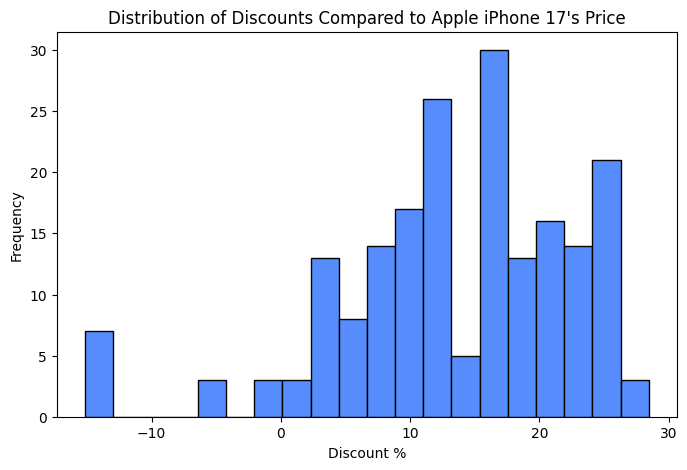

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(model_discount["discount_percent"], bins=20, edgecolor="black")
plt.xlabel("Discount %")
plt.ylabel("Frequency")
plt.title("Distribution of Discounts Compared to Apple iPhone 17's Price")
plt.show()